In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate.micro_cond import adherence_table

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [2]:
# Plot config
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}
MODEL_LABELS = {'ca': 'CA', 'ca-film': 'CA-Film'}

print("Plot config defined.")

Plot config defined.


In [3]:
"""
Get generated data.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

ALL_FILES = sorted(f.name for f in next(iter(MODEL_DIRS.values())).glob('*.json'))

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for filename in ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        mean_w = t_tgt / (100.0 * T)
        var_w = (r_tgt / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
        std_w = np.sqrt(np.maximum(var_w, 1e-12))
        samples = samples * std_w + mean_w  # back to original log-return scale

        gen_data[model][filename] = {
            'n_samples': samples.shape[0],
            'trend_target': t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target': r_tgt,
            'rv_achieved': np.sum((samples * 100) ** 2, axis=1),
        }

print("Generated data loaded.")


Generated data loaded.


In [4]:
"""
3.1 - Trend adherence.
"""

print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, gen_data, ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json         -10.00    -10.0515      3.6761      0.0515
t-10r30i8v35.json         -10.00    -10.0797      4.7365      0.0797
t-10r40i5v20.json         -10.00     -9.9807      3.1188      0.0193
t-10r40i8v35.json         -10.00    -10.0393      2.7152      0.0393
t-10r50i5v20.json         -10.00    -10.0978      4.1511      0.0978
t-10r50i8v35.json         -10.00    -10.0809      6.4886      0.0809
t-10r60i5v20.json         -10.00    -10.0029      4.2731      0.0029
t-10r60i8v35.json         -10.00    -10.1478      4.3080      0.1478
t-10r70i5v20.json         -10.00    -10.2175      5.4419      0.2175
t-10r70i8v35.json         -10.00    -10.1579      4.6595      0.1579
t-5r30i5v20.json           -5.00     -5.0910      4.0248      0.0910
t-5r30i8v35.json           -5.00 

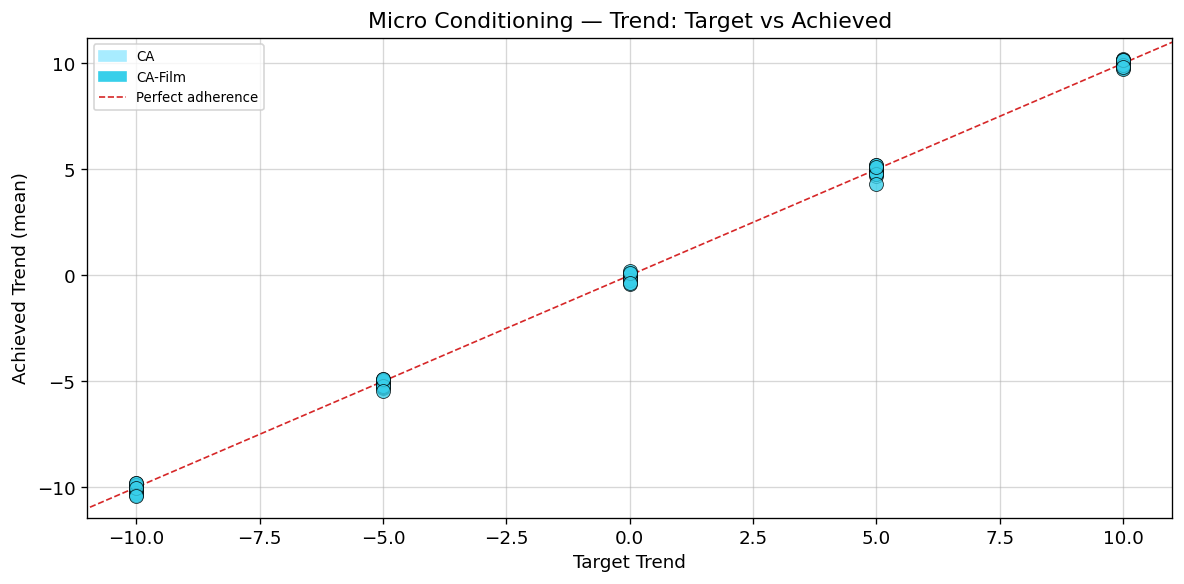

In [5]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [6]:
"""
3.2 - Realized volatility adherence.
"""

print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, gen_data, ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json          30.00     37.7024    128.3515      7.7024
t-10r30i8v35.json          30.00     37.1452    171.8800      7.1452
t-10r40i5v20.json          40.00     47.5835    114.3869      7.5835
t-10r40i8v35.json          40.00     46.4671     83.7810      6.4671
t-10r50i5v20.json          50.00     62.7278    212.2121     12.7278
t-10r50i8v35.json          50.00     68.1951    325.9896     18.1951
t-10r60i5v20.json          60.00     72.5889    211.4143     12.5889
t-10r60i8v35.json          60.00     81.0978    493.7512     21.0978
t-10r70i5v20.json          70.00     81.4412    133.4452     11.4412
t-10r70i8v35.json          70.00     85.3085    190.2612     15.3085
t-5r30i5v20.json           30.00     40.1160    136.1723     10.1160
t-5r30i8v35.json          

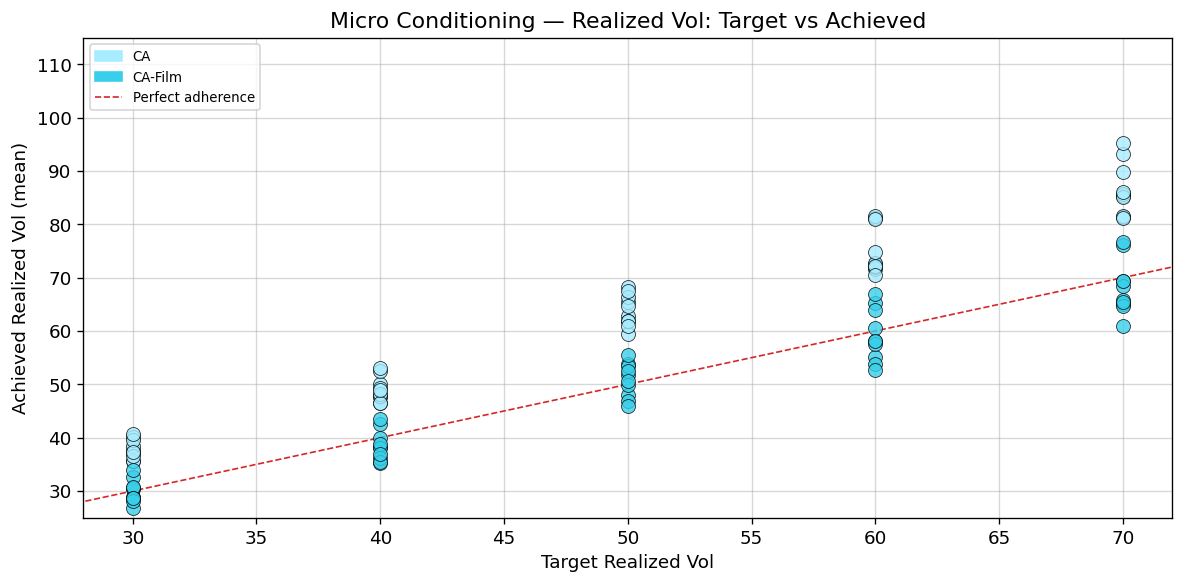

In [7]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylim(25, 115)
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()

